In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)

X_xor = torch.tensor([[0.0, 0.0],   # 0   0   0
                      [0.0, 1.0],   # 1   0   1
                      [1.0, 0.0],   # 1   0   1
                      [1.0, 1.0]])  # 1   1   0

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]])

In [107]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu( self.hidden(x) )
        x = torch.sigmoid( self.output(x) )
        return x

model = XORNet()
for p in model.parameters():
    print(f"학습가능한 파라미터 수 : {p.numel()}")
    print(f"가중치 및 바이어스 값: {p}")

학습가능한 파라미터 수 : 8
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153]], requires_grad=True)
학습가능한 파라미터 수 : 4
가중치 및 바이어스 값: Parameter containing:
tensor([ 0.6233, -0.5188,  0.6146,  0.1323], requires_grad=True)
학습가능한 파라미터 수 : 4
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True)
학습가능한 파라미터 수 : 1
가중치 및 바이어스 값: Parameter containing:
tensor([0.3854], requires_grad=True)


In [108]:
criterion = nn.BCELoss()
optimizer = optim.Adam( model.parameters(), lr=1e-2 ) # 0.01, 1e+2 -> 100.0

epochs = 1000

loss_history = []
for epoch in range(epochs):
    # 기울기 초기화 (zero_grad())
    optimizer.zero_grad()
    # forward : 순전파 (예측)
    predict = model(X_xor)
    # loss 계산 
    loss = criterion(predict, y_xor)
    # backward : 역전파(Chain rule), 각 계산 스텝별 기울기 계산
    loss.backward()
    # 업데이트 : 이전 기울기에 - backward 에서 구한 기울기
    optimizer.step()
    # loss_history loss 저장
    loss_history.append(loss.item())

    if (epoch+1)%200 == 0:
        print((f"{epoch+1} / {epochs}, loss : {loss.item()}"))



200 / 1000, loss : 0.17800430953502655
400 / 1000, loss : 0.025707358494400978
600 / 1000, loss : 0.009478487074375153
800 / 1000, loss : 0.004902699496597052
1000 / 1000, loss : 0.002985338680446148


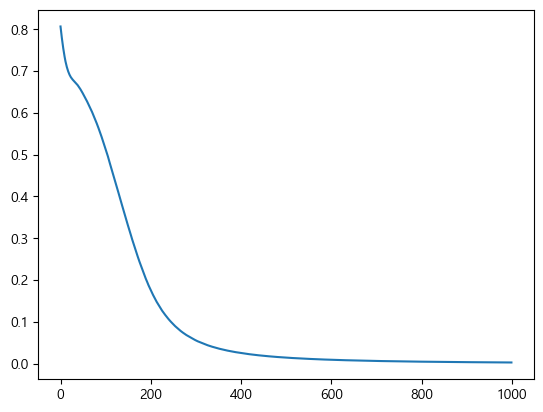

In [109]:
import matplotlib.pyplot as plt

plt.plot(range(epoch+1), loss_history)
plt.show()

In [110]:
from sklearn.datasets import load_iris
X = torch.tensor( load_iris().data, dtype=torch.float32 )
y = torch.tensor( load_iris().target, dtype=torch.long )

train_dataset = TensorDataset(X, y)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
# for data in train_loader:
#     print(data)

model = XORNet()

epochs = 1000
loss_history = []
for epoch in range(epochs):
    for x in train_loader:
        # 기울기 초기화 (zero_grad())
        optimizer.zero_grad()
        # forward : 순전파 (예측)
        predict = model(X_xor)
        # loss 계산 
        loss = criterion(predict, y_xor)
        # backward : 역전파(Chain rule), 각 계산 스텝별 기울기 계산
        loss.backward()
        # 업데이트 : 이전 기울기에 - backward 에서 구한 기울기
        optimizer.step()
        # loss_history loss 저장
        loss_history.append(loss.item())

    if (epoch+1)%200 == 0:
        print((f"{epoch+1} / {epochs}, loss : {loss.item()}"))


200 / 1000, loss : 0.6739367842674255
400 / 1000, loss : 0.6739367842674255
600 / 1000, loss : 0.6739367842674255
800 / 1000, loss : 0.6739367842674255
1000 / 1000, loss : 0.6739367842674255


In [111]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로드
iris = load_iris()
X_np, y_np = iris.data, iris.target
print(f"전체 데이터: {X_np.shape[0]}개, 특성 {X_np.shape[1]}개, 종류 {len(set(y_np))}개")
print(f"종 이름: {iris.target_names.tolist()}")

X_train_full,X_test,y_train_full,y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

#정규화 (특성 스케일 통일)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_valid_t = torch.tensor(X_valid, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print(f"\n학습 데이터: {len(X_train_t)}개, 검증 데이터: {len(X_valid_t)}, 테스트 데이터: {len(X_test_t)}개")
print(f"미니배치 크기: 16, 에폭당 반복 횟수: {len(train_loader)}")

전체 데이터: 150개, 특성 4개, 종류 3개
종 이름: ['setosa', 'versicolor', 'virginica']

학습 데이터: 90개, 검증 데이터: 30, 테스트 데이터: 30개
미니배치 크기: 16, 에폭당 반복 횟수: 6


In [112]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 3)
    
    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.layer3(x)
        return x

model_iris = IrisClassifier()
print(model_iris)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model_iris.parameters())}")

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
)

총 파라미터 수: 243


In [113]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iris.parameters(), lr=1e-2)

In [114]:
epochs = 100
epoch_losses, epoch_val_losses = [], []
epoch_acces, epoch_val_acces = [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_iris(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        acc = torch.softmax(predictions, axis=1)
        _, class_index = torch.max(acc,dim=1)
        acc = sum(class_index == batch_y) / len(batch_y)
        epoch_acc += acc.item()
    avg_acc = epoch_acc / len(train_loader)
    epoch_acces.append(avg_acc)

    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    

    with torch.no_grad():
        val_predict = model_iris(X_valid_t)
        val_loss = criterion(val_predict, y_valid_t).item()
        epoch_val_losses.append(val_loss)

        _, val_acc_index = torch.max(torch.softmax(val_predict, axis=1), dim=1)
        val_acc = sum(val_acc_index == y_valid_t) / len(y_valid_t)
        epoch_val_acces.append(val_acc)

    if (epoch +1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] \
        - 평균 Loss: {avg_loss:.4f}, val loss :{val_loss:.4f} \
        - 평균 ACC : {avg_acc:.4f}")

Epoch [ 20/100]         - 평균 Loss: 0.0307, val loss :0.2287         - 평균 ACC : 0.9896
Epoch [ 40/100]         - 평균 Loss: 0.0076, val loss :0.3315         - 평균 ACC : 1.0000
Epoch [ 60/100]         - 평균 Loss: 0.0028, val loss :0.3769         - 평균 ACC : 1.0000
Epoch [ 80/100]         - 평균 Loss: 0.0014, val loss :0.4439         - 평균 ACC : 1.0000
Epoch [100/100]         - 평균 Loss: 0.0009, val loss :0.4632         - 평균 ACC : 1.0000


테스트 정확도: 90.0% (27/30)


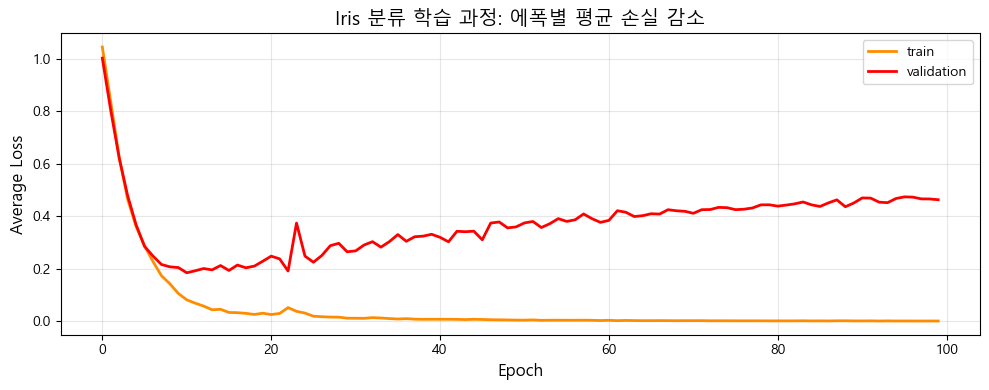

In [115]:
with torch.no_grad():
    test_outputs = model_iris(X_test_t)
    _, predicted = torch.max(test_outputs, dim=1) # 가장 높은 확률의 클래스 선택

    correct = ( predicted == y_test_t ).sum().item()
    total = y_test_t.size(0)
    accuracy = correct / total * 100

print("=" * 50)
print(f"테스트 정확도: {accuracy:.1f}% ({correct}/{total})")
print("=" * 50)

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
# 손실 감소 그래프
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_losses, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Iris 분류 학습 과정: 에폭별 평균 손실 감소', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


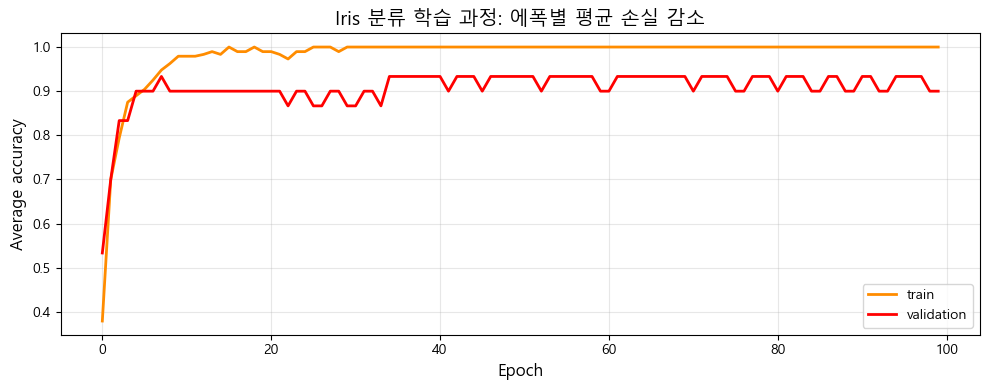

In [116]:
# 손실 감소 그래프
plt.figure(figsize=(10, 4))
plt.plot(epoch_acces, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_acces, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average accuracy', fontsize=12)
plt.title('Iris 분류 학습 과정: 에폭별 평균 손실 감소', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [121]:
x = torch.tensor([2, 0 , -1])
torch.exp(x)

tensor([7.3891, 1.0000, 0.3679])